# 先行研究の再現Part1：パラメータの初期値作成

In [ ]:
# Shared raw data in repository; generated data in this study
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        p
        for p in (Path.cwd(), *Path.cwd().parents)
        if (p / "setup-env.ps1").is_file() and (p / "study_with_me").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from inside paper_study.")
PROJECT_DIR = (
    REPO_ROOT / "Merton_Poisson_Lognormal_Model_Study_and_Negative_Binomial_Extension"
)
RAW_DATA_DIR = REPO_ROOT / "data" / "raw"
PROJECT_DATA_DIR = PROJECT_DIR / "data"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import pandas as pd
import matplotlib

print(pd.__version__)
print(matplotlib.__version__)

3.0.1
3.10.8


In [2]:
import matplotlib.pyplot as plt

print(plt.matplotlib.__version__)

3.10.8


In [3]:
import numpy as np

print(np.__version__)

2.4.2


In [4]:
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy.stats import norm
from scipy.integrate import quad

## モデル
潜在マクロ因子の確率モデル
$$
y_t \sim \mathcal{N}(0,1)\ ,\ d_i = \mathbb{E}[y_t y_{t+i}]
$$
マートンモデル近似後の条件付きデフォルト数分布
$$
X_t|y_t \sim \text{Poisson}(\lambda_t)\ , \ \lambda_t = \lambda_0 \exp{(\alpha y_t)} \sim \mathcal{LN}(\log \lambda_0 , \alpha^2)
$$
ただし、
$$
\alpha^2 = \frac{\rho_A}{1-\rho_A}\beta^2 \ , \ \beta=1.596
$$
ここで$\rho_A$は、標準化された企業の資産を$U_{it}$($i$は企業、$t$は時間)として
$$
U_{it} = \sqrt{\rho_A} y_t + \sqrt{1-\rho_A}\epsilon_{it}
$$


## Figure4の再現
投資適格（IG）、
投機的格付け（SG）
$$
k^{*}_t = 3000\frac{k_t}{n_t}
$$

In [5]:
# read csv
from pathlib import Path

csv_path = RAW_DATA_DIR / "default_counts/M.csv"
df = pd.read_csv(csv_path)

# set index to Year
df["Year"] = pd.to_datetime(df["Year"], format="%Y")
df = df.set_index("Year")
print("===to DatetimeIndex===")
print(type(df.index))
print("====DatetimeIndex====")

# normalization
df["SG_norm"] = df["D_SG"] / df["SG"] * 3000
df["IG_norm"] = df["D_IG"] / df["IG"] * 3000
df["ALL_norm"] = df["D_ALL"] / df["ALL"] * 3000

# view dataframe
df.head()

===to DatetimeIndex===
<class 'pandas.DatetimeIndex'>
====DatetimeIndex====


,SG,D_SG,IG,D_IG,ALL,D_ALL,SG_norm,IG_norm,ALL_norm
Year,,,,,,,,,
1920-01-01,831,25,1843,8,2674,33,90.252708,13.022246,37.023186
1921-01-01,1163,25,1833,7,2996,32,64.488392,11.456628,32.042724
1922-01-01,1305,23,1972,10,3277,33,52.873563,15.212982,30.210558
1923-01-01,1290,22,2068,5,3358,27,51.162791,7.253385,24.121501
1924-01-01,1297,37,2175,3,3472,40,85.582113,4.137931,34.562212


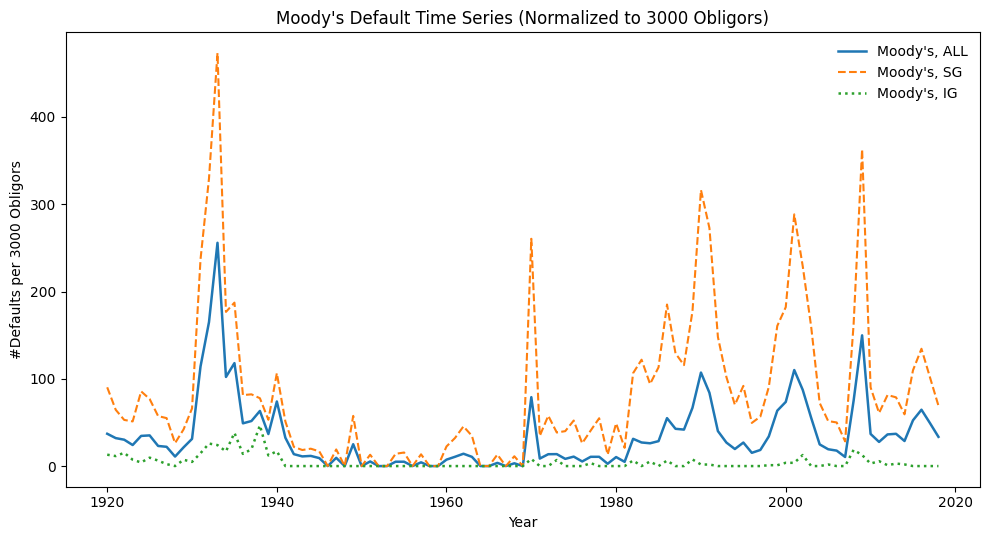

In [6]:
# Figure 4
plt.figure(figsize=(10, 5.5))
plt.plot(df.index, df["ALL_norm"], label="Moody's, ALL", linewidth=1.8)
plt.plot(df.index, df["SG_norm"], "--", label="Moody's, SG", linewidth=1.5)
plt.plot(df.index, df["IG_norm"], ":", label="Moody's, IG", linewidth=1.8)

plt.title("Moody's Default Time Series (Normalized to 3000 Obligors)")
plt.xlabel("Year")
plt.ylabel("#Defaults per 3000 Obligors")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## モデルの統計量

### 理論値
強度$\lambda_t$について
$$
\mathbb{E}[\lambda_t] = \exp{(\log{\lambda_0} + \frac{\alpha^2}{2})} = \bar{\lambda} \ , \ Var(\lambda_t) = \bar{\lambda}^2 (\exp{\alpha^2}-1) = \bar{V}
$$
無条件のデフォルト$X_t$については、条件付きのデフォルト$X_t|y_t$と期待値の繰り返し公式を利用して
$$
\mathbb{E}[X_t] = \mathbb{E}[\mathbb{E}[X_t|y_t]] = \mathbb{E}[\lambda_t]
$$
分散も同様に
$$
Var(X_t) = \mathbb{E}[Var[X_t|y_t]] + Var[\mathbb{E}[X_t|y_t]] = \mathbb{E}[\lambda_t] + Var[\lambda_t]
$$
分散比の理論値は
$$
\frac{Var(X_t)}{\mathbb{E}[X_t]} = 1 + \frac{\bar{V}}{\bar{\lambda}} = 1 + \bar{\lambda} (\exp{\alpha^2}-1)
$$

- $\alpha = 0$ならデフォルト数は条件付きではないただのポアソン分布
- $\alpha$が大きいほど、$\lambda_t$の揺れが大きくなり、過分散が強くなる

In [7]:
def summary_stats(s):
    return pd.Series({
        "mean": s.mean(),
        "var": s.var(),
        "std": s.std(),
        "var/mean": s.var() / s.mean() if s.mean() != 0 else float("nan"),
        "min": s.min(),
        "max": s.max(),
        "skew": s.skew(),  # 歪度
        "kurtosis": s.kurt(),  # 尖度
    })

In [8]:
cols = ["D_ALL", "D_SG", "D_IG"]

summary_table = pd.DataFrame({col: summary_stats(df[col]) for col in cols}).T
summary_table

,mean,var,std,var/mean,min,max,skew,kurtosis
D_ALL,35.626263,2425.256854,49.246897,68.074973,0.0,272.0,2.279845,6.198378
D_SG,33.575758,2216.634508,47.081148,66.018898,0.0,258.0,2.283075,6.130841
D_IG,2.050505,13.477015,3.671105,6.572534,0.0,21.0,2.609931,8.187848


In [9]:
# normalization stats
cols_norm = ["ALL_norm", "SG_norm", "IG_norm"]

summary_norm_table = pd.DataFrame({col: summary_stats(df[col]) for col in cols_norm}).T
summary_norm_table

,mean,var,std,var/mean,min,max,skew,kurtosis
ALL_norm,34.691534,1647.442336,40.588697,47.488311,0.0,255.813953,2.548609,9.228282
SG_norm,84.374361,7839.103560,88.538712,92.908598,0.0,473.288815,1.920421,4.305552
IG_norm,4.308403,65.276572,8.079392,15.150989,0.0,46.632124,2.839495,9.876171


### モーメント法を用いた計算

ベイズ推定をする際の最初の事前分布パラメータとしてモーメント法を用いた推定を実施する。※論文では最尤推定としているが、ここに精度を必要とはしないと判断し、より簡単な推定法で実施
- $y_t$ の時間相関を無視
- 時系列依存の影響が残る

$$
\bar{x}  \simeq \bar{\lambda} \ ,\  
s^2 \simeq \bar{\lambda} + \bar{\lambda^2} (\exp{α^2} - 1)
$$

から
$$
\hat{\alpha}_{moment} = \sqrt{\log{\left( \frac{s^2 - \bar{\lambda}}{\bar{\lambda}^2} +1  \right)}}
$$

In [10]:
alpha_table = summary_norm_table.copy()

alpha_table["var_lambda"] = alpha_table["var"] - alpha_table["mean"]

alpha_table["alpha_mom"] = np.sqrt(
    np.log((alpha_table["var"] - alpha_table["mean"]) / (alpha_table["mean"] ** 2) + 1)
)

alpha_table[["mean", "var", "var_lambda", "var/mean", "alpha_mom"]]

,mean,var,var_lambda,var/mean,alpha_mom
ALL_norm,34.691534,1647.442336,1612.750802,47.488311,0.922047
SG_norm,84.374361,7839.103560,7754.729199,92.908598,0.858386
IG_norm,4.308403,65.276572,60.968169,15.150989,1.206236


## Table1の再現

($\lambda_0$,$\alpha_0$) の初期値 $\to y_t$ 復元$\to$ 自己相関$\text{ACF}(y_t)$ $\to$ $(\theta_0 , \gamma_0)$ の初期値

In [11]:
csv_path_M = RAW_DATA_DIR / "default_counts/M.csv"
M = pd.read_csv(csv_path_M)

M["Year"] = pd.to_datetime(M["Year"], format="%Y")
M = M.set_index("Year")

In [12]:
csv_path_SP = RAW_DATA_DIR / "default_counts/SP.csv"
SP = pd.read_csv(csv_path_SP)

SP["year"] = pd.to_datetime(SP["year"], format="%Y")
SP = SP.set_index("year")
SP.index.name = "Year"

In [13]:
# normalization
def normalize_3000(df, obligor_col, default_col):
    return 3000.0 * df[default_col] / df[obligor_col]


# make normalization dataframe
def make_normalized_dataset(df_source):
    df_out = pd.DataFrame(index=df_source.index.copy())

    df_out["ALL"] = normalize_3000(df_source, "ALL", "D_ALL")
    df_out["SG"] = normalize_3000(df_source, "SG", "D_SG")
    df_out["IG"] = normalize_3000(df_source, "IG", "D_IG")

    return df_out

In [14]:
# S&P 1981 - 2018
df_sp = make_normalized_dataset(SP)

# Moody's 1920 - 2018
df_moodys_a = make_normalized_dataset(M)

# Moody's 1980 - 2018
df_moodys_b = make_normalized_dataset(M.loc["1980":"2018"])

In [15]:
df_sp.head()

,ALL,SG,IG
Year,,,
1981-01-01,4.431315,18.691589,0.000000
1982-01-01,36.376605,132.743363,5.644403
1983-01-01,23.206751,89.020772,2.764977
1984-01-01,27.851459,99.173554,5.240175
1985-01-01,30.131827,116.788321,0.000000


In [16]:
df_moodys_a

,ALL,SG,IG
Year,,,
1920-01-01,37.023186,90.252708,13.022246
1921-01-01,32.042724,64.488392,11.456628
1922-01-01,30.210558,52.873563,15.212982
1923-01-01,24.121501,51.162791,7.253385
1924-01-01,34.562212,85.582113,4.137931
...,...,...,...
2014-01-01,28.710544,59.288538,1.890955
2015-01-01,52.437460,109.768379,0.000000
2016-01-01,64.561734,134.401570,0.000000


In [17]:
df_moodys_b

,ALL,SG,IG
Year,,,
1980-01-01,10.318143,48.979592,0.000000
1981-01-01,4.858300,20.905923,0.000000
1982-01-01,31.224980,106.451613,6.389776
1983-01-01,27.027027,121.875000,0.000000
1984-01-01,26.104418,94.017094,5.249344
1985-01-01,28.554432,113.207547,0.000000
1986-01-01,54.905948,185.046729,6.284916
1987-01-01,42.699725,129.166667,0.000000
1988-01-01,41.789785,115.654206,0.000000


## Table1.先行研究における初期値$\lambda_0$ , $\alpha_0$ , $\theta_0$ , $\gamma_0$

In [18]:
paper_results = [
    # dataset, period, lambda0, alpha, theta, gamma
    ["Moodys ALL", "1920-2023", 18.1, 1.4, 0.890, 0.64],
    ["Moodys SG", "1920-2023", 42.4, 1.6, 0.880, 0.63],
    ["Moodys IG", "1920-2023", 0.6, 2.5, 0.84, 0.74],
    ["Moodys ALL", "1980-2023", 39.9, 0.61, 0.75, 1.0],
    ["Moodys SG", "1980-2023", 107.3, 0.58, 0.72, 1.24],
    ["Moodys IG", "1980-2023", 1.0, 1.6, 0.70, 0.95],
    ["SP ALL", "1981-2023", 36.8, 0.62, 0.74, 1.01],
    ["SP SG", "1981-2023", 100.2, 0.62, 0.74, 0.86],
    ["SP IG", "1981-2023", 1.0, 1.5, 0.68, 0.98],
]

paper_df = pd.DataFrame(
    paper_results,
    columns=["dataset", "period", "lambda0_mle", "alpha_mle", "theta_acf", "gamma_acf"],
)

paper_df

,dataset,period,lambda0_mle,alpha_mle,theta_acf,gamma_acf
0,Moodys ALL,1920-2023,18.1,1.40,0.89,0.64
1,Moodys SG,1920-2023,42.4,1.60,0.88,0.63
2,Moodys IG,1920-2023,0.6,2.50,0.84,0.74
3,Moodys ALL,1980-2023,39.9,0.61,0.75,1.00
4,Moodys SG,1980-2023,107.3,0.58,0.72,1.24
5,Moodys IG,1980-2023,1.0,1.60,0.70,0.95
6,SP ALL,1981-2023,36.8,0.62,0.74,1.01
7,SP SG,1981-2023,100.2,0.62,0.74,0.86
8,SP IG,1981-2023,1.0,1.50,0.68,0.98


## パラメータ推定の初期値$\lambda_0$ , $\alpha_0$を決定
初期値はさらに簡単なモーメント法で実施する。

ベイズ推定の初期値で使うので実験的に簡単な方法で

$$
\hat{\alpha}_{0,moment} = \sqrt{\log{\left( \frac{s^2 - \bar{\lambda}}{\bar{\lambda}^2} +1  \right)}}\ , \ \hat{\lambda}_{0,moment} = \bar{\lambda}\exp{(-\frac{\alpha^2}{2})}
$$

In [19]:
def estimate_initial_lambda_alpha(k_star):
    """
    k_star : 1次元 array-like
        正規化カウント k_t^*
    """
    k = np.asarray(k_star, dtype=float)

    k_bar = np.mean(k)
    s2 = np.var(k, ddof=0)

    # s2 <= k_bar
    # not -log
    tmp = (s2 - k_bar) / (k_bar**2) + 1.0
    tmp = max(tmp, 1e-12)

    alpha0 = np.sqrt(np.log(tmp))
    lambda0 = k_bar * np.exp(-0.5 * alpha0**2)

    return lambda0, alpha0

In [20]:
# sp
for col in ["ALL", "SG", "IG"]:
    lambda0_init, alpha0_init = estimate_initial_lambda_alpha(df_sp[col])
    print(col, lambda0_init, alpha0_init)

ALL 36.61002724160115 0.6028533508737487
SG 103.69254176480413 0.6004225085688487
IG 1.7600916215243985 0.9274522882196238


In [21]:
# moodys_a
for col in ["ALL", "SG", "IG"]:
    lambda0_init, alpha0_init = estimate_initial_lambda_alpha(df_moodys_a[col])
    print(col, lambda0_init, alpha0_init)

ALL 22.745633789645154 0.9188280249138175
SG 58.5288088156419 0.8552712826443558
IG 2.090131620842137 1.202780407761581


In [22]:
# moodys_b
for col in ["ALL", "SG", "IG"]:
    lambda0_init, alpha0_init = estimate_initial_lambda_alpha(df_moodys_b[col])
    print(col, lambda0_init, alpha0_init)

ALL 37.61148749157607 0.6025990130847418
SG 105.17921631499536 0.576244085334094
IG 1.3849902760762378 1.0956661238947907


### $y_t$の復元
$$ 
k_t \simeq \mathbb{E}[X_t|y_t] = \lambda_t = \lambda_0 \exp{(\alpha y_t)}
$$
から逆算して
$$
y_t = \frac{\log{(k_t + 0.5)} - \log{\lambda_0}}{\alpha}
$$
なお、$+0.5$は$k_t=0$の時を考えた補正項

### 参考：マクロ要因に影響を与える出来事
以下の表にあるような時期には$y_t$は大きくなっていることが望ましいという直感
| No | 年代        | イベント名      | 概要         | 経済への影響       | y_t の期待挙動  |
| -- | --------- | ---------- | ---------- | ------------ | ---------- |
| 1  | 1929–1933 | 世界恐慌       | 株価大暴落・銀行破綻 | 大量倒産・失業増加    | **最大級に上昇** |
| 2  | 1939–1945 | 第二次世界大戦    | 戦時経済・統制    | 市場機能の歪み      | 上昇（やや特殊）   |
| 3  | 1973–1975 | 第一次オイルショック | 原油価格急騰     | インフレ＋景気後退    | 明確に上昇      |
| 4  | 1979–1982 | 第二次オイルショック | 再度の原油高     | 長期停滞・金融引き締め  | 上昇         |
| 5  | 1987–1991 | S&L危機      | 米金融機関破綻    | 信用収縮         | 中程度に上昇     |
| 6  | 2000–2002 | ITバブル崩壊    | テック株暴落     | 企業破綻増加（SG中心） | 上昇         |
| 7  | 2008–2009 | リーマンショック   | 世界金融危機     | 信用市場崩壊       | **最大級に上昇** |


In [21]:
def restore_y(k_star, lambda0, alpha):
    k = np.asarray(k_star, dtype=float)
    y = (np.log(k + 0.5) - np.log(lambda0)) / alpha
    return y


def plot_y(df, title):
    plt.figure(figsize=(10, 5))

    for col in ["ALL", "SG", "IG"]:
        # 初期値推定
        lambda0, alpha0 = estimate_initial_lambda_alpha(df[col])

        # y復元
        y = restore_y(df[col], lambda0, alpha0)

        plt.plot(df.index, y, label=col)

    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel("y_t")
    plt.legend()
    plt.grid(True)

    plt.show()

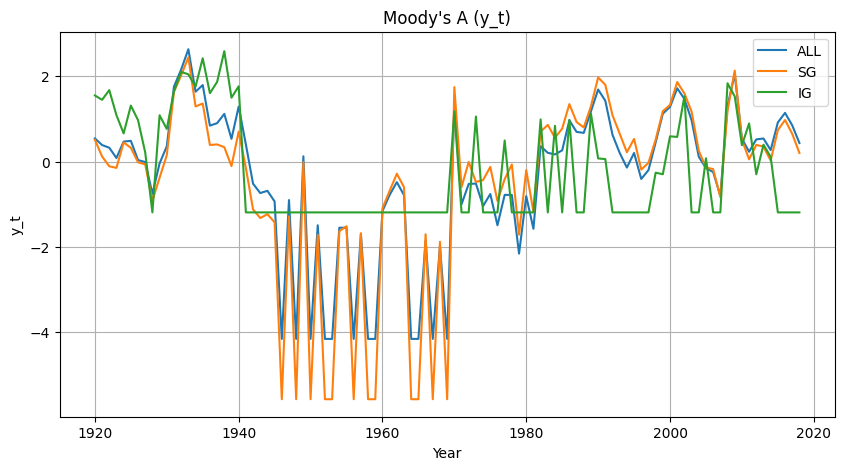

In [22]:
# moodys_a
y_moodys_a = pd.DataFrame(index=df_moodys_a.index)

for col in ["ALL", "SG", "IG"]:
    lambda0_init, alpha0_init = estimate_initial_lambda_alpha(df_moodys_a[col])
    y_moodys_a[col] = restore_y(df_moodys_a[col], lambda0_init, alpha0_init)

plot_y(df_moodys_a, "Moody's A (y_t)")

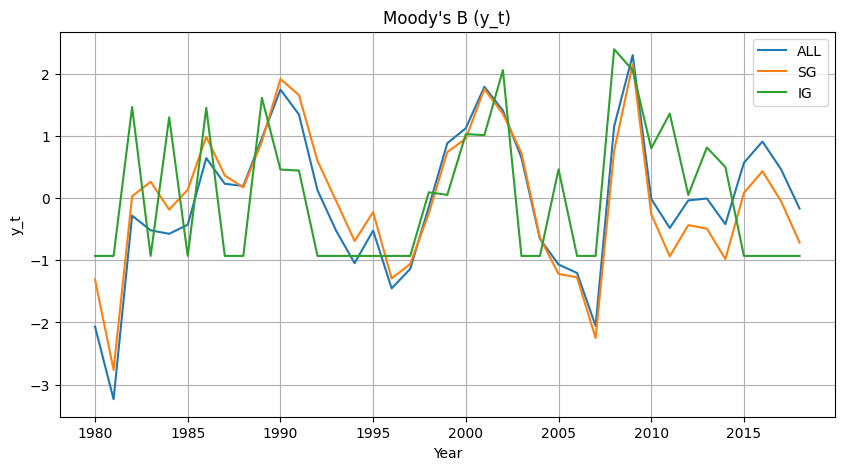

In [23]:
# moodys_b
y_moodys_b = pd.DataFrame(index=df_moodys_b.index)

for col in ["ALL", "SG", "IG"]:
    lambda0_init, alpha0_init = estimate_initial_lambda_alpha(df_moodys_b[col])
    y_moodys_b[col] = restore_y(df_moodys_b[col], lambda0_init, alpha0_init)

plot_y(df_moodys_b, "Moody's B (y_t)")

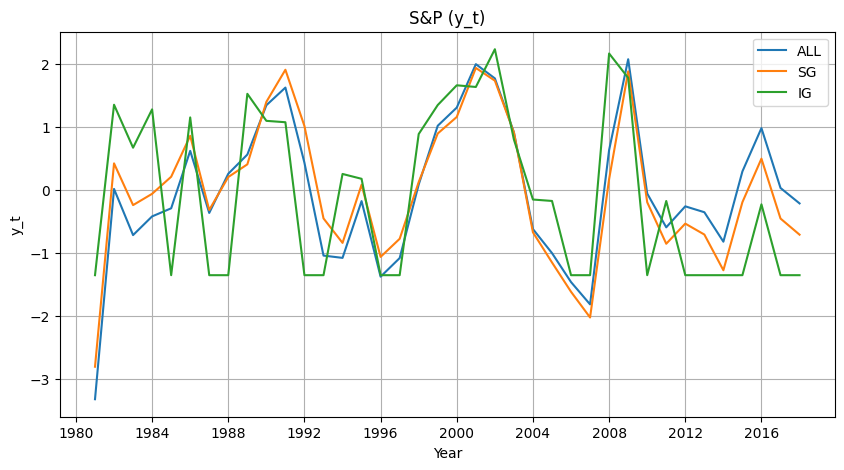

In [24]:
# SP
y_sp = pd.DataFrame(index=df_sp.index)

for col in ["ALL", "SG", "IG"]:
    lambda0_init, alpha0_init = estimate_initial_lambda_alpha(df_sp[col])
    y_sp[col] = restore_y(df_sp[col], lambda0_init, alpha0_init)

plot_y(df_sp, "S&P (y_t)")

## 自己相関$\text{ACF}(y_t)$　Figer5の一部に対応
### 自己相関
$$
\rho(h) = \text{Corr}(y_t , y_{t + h}) = d_h
$$

### 標本自己相関

時系列 $ \{y_t\}_{t=1}^T $ に対して：

#### 平均
$$
\bar{y} = \frac{1}{T} \sum_{t=1}^{T} y_t
$$

#### 分散（ラグ0の共分散）
$$
\hat{\gamma}(0) = \frac{1}{T} \sum_{t=1}^{T} (y_t - \bar{y})^2
$$

#### ラグ $h$ の自己共分散
$$
\hat{\gamma}(h) = \frac{1}{T} \sum_{t=1}^{T-h} (y_t - \bar{y})(y_{t+h} - \bar{y})
$$

#### 標本自己相関（ACF）
$$
\hat{\rho}(h) = \frac{\hat{\gamma}(h)}{\hat{\gamma}(0)}
$$

In [25]:
import statsmodels

print(statsmodels.__version__)

0.14.6


In [26]:
from statsmodels.tsa.stattools import acf

In [27]:
def plot_acf_basic(y, title, nlags=20):
    acf_vals = acf(y, nlags=nlags, fft=False)

    plt.figure(figsize=(8, 4))
    plt.stem(range(len(acf_vals)), acf_vals)
    plt.xlabel("Lag")
    plt.ylabel("ACF")
    plt.title(title)
    plt.grid(True)
    plt.show()

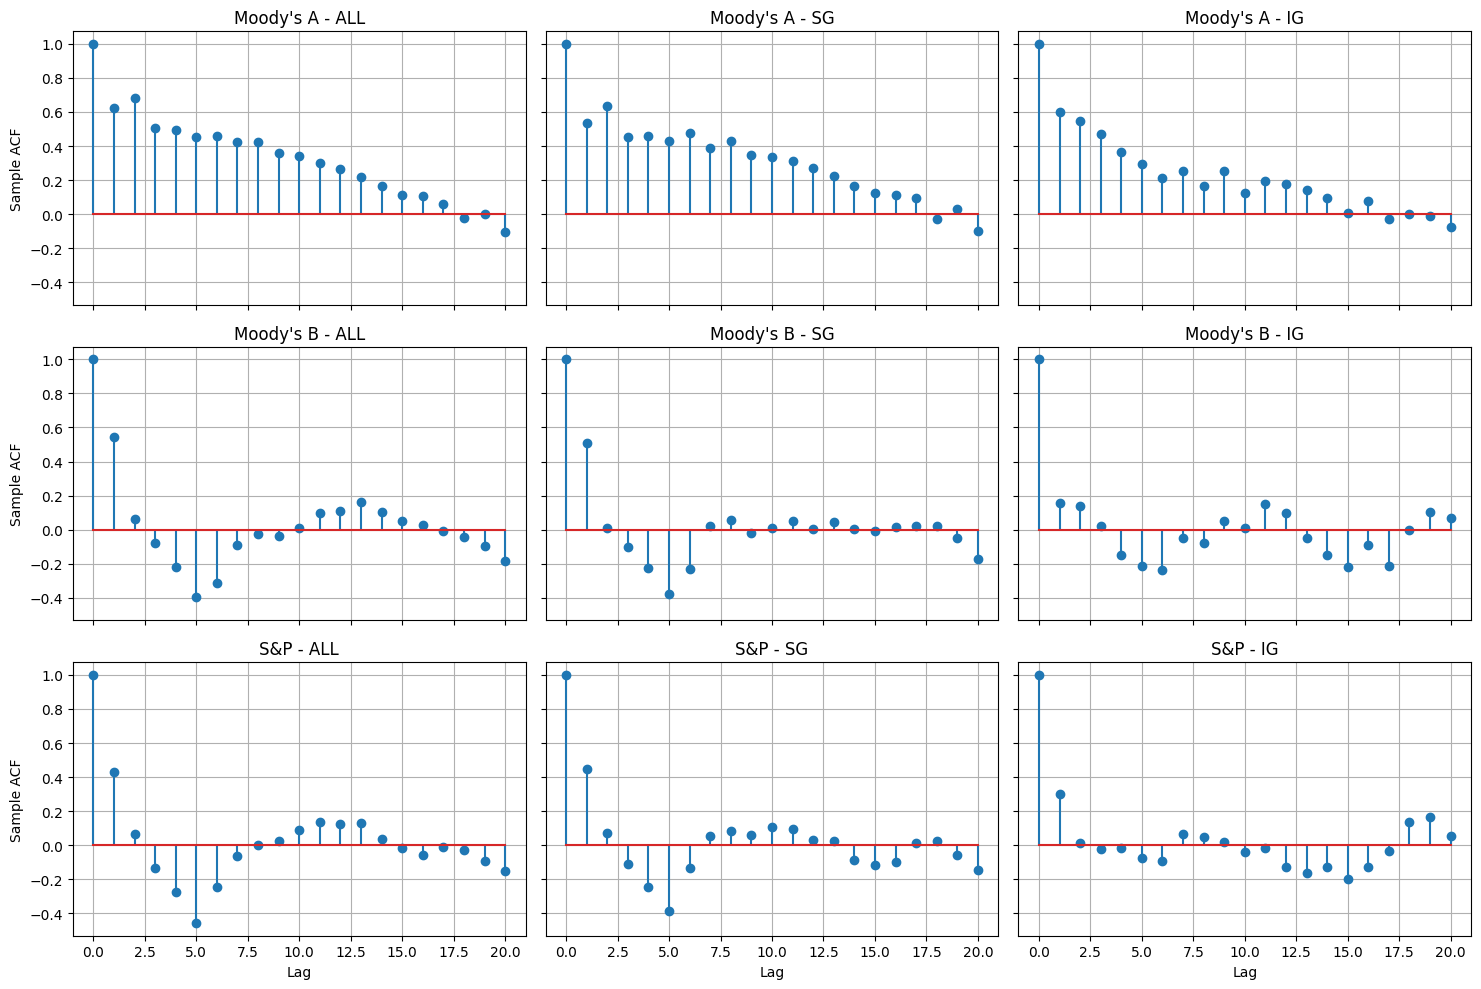

In [28]:
datasets = {
    "Moody's A": y_moodys_a,
    "Moody's B": y_moodys_b,
    "S&P": y_sp,
}

cols = ["ALL", "SG", "IG"]

fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True, sharey=True)

for i, (name, y_df) in enumerate(datasets.items()):
    for j, col in enumerate(cols):
        ax = axes[i, j]
        acf_vals = acf(y_df[col], nlags=20, fft=False)

        ax.stem(range(len(acf_vals)), acf_vals)
        ax.set_title(f"{name} - {col}")
        ax.grid(True)

        if i == 2:
            ax.set_xlabel("Lag")
        if j == 0:
            ax.set_ylabel("Sample ACF")

plt.tight_layout()
plt.show()

標本自己相関をみて

- Moody’s (1920 - ) → 長期記憶?
- Moody’s (1980 - ) → 短期記憶?
- S&P → 短期記憶?

## $\theta_0 , \gamma_0$の初期値
問題点整理
- 論文のフィット仕様が不明
- 指数減衰・べき乗減衰では負の自己相関が示せない
- 論文が復元した$y_t$が不明
- 標本が少なくACF自体が不安定


>ここでは、初期値について論文との厳密な整合性にこだわらない
>
>のちにこちらで再現した初期推定と論文の初期推定を両方やってある程度最終的なベイズ推定値が出れば問題ないという立場をとる

### 指数減衰
$$
d_h = \theta^h, \qquad 0 \le \theta \le 1
$$

### 推定量
$$
\hat{\theta}
=
\operatorname*{argmin}_{0 \le \theta \le 1}
\sum_{h=1}^H
\frac{1}{h}
\left(
\hat{\rho}(h) - \theta^h
\right)^2
$$

In [30]:
import scipy

print(scipy.__version__)

1.17.1


In [31]:
from scipy.optimize import minimize_scalar

In [69]:
def fit_theta_by_acf(
    y, H=20, method="weighted", fft=False, adjusted=False, weight_type="inverse_lag"
):
    """
    標本ACFに対して、指数減衰
        rho(h) = theta^h
    をフィットして theta を推定する。

    Parameters
    ----------
    y : array-like
        時系列データ
    H : int, default=20
        使用する最大ラグ
    method : {"ls", "weighted"}, default="weighted"
        - "ls"       : 等重み最小二乗
        - "weighted" : 重み付き最小二乗
    fft : bool, default=False
        statsmodels.tsa.stattools.acf に渡す引数
    adjusted : bool, default=False
        statsmodels.tsa.stattools.acf に渡す引数
    weight_type : {"inverse_lag", "inverse_lag_sq"}, default="inverse_lag"
        method="weighted" のときの重み
        - "inverse_lag"    : w_h = 1/h
        - "inverse_lag_sq" : w_h = 1/h^2

    Returns
    -------
    result : dict
        推定結果
    """
    y = pd.Series(y).dropna().astype(float).values

    if len(y) <= H:
        raise ValueError(f"データ長 {len(y)} に対して H={H} は大きすぎます。")

    rho_hat = acf(y, nlags=H, fft=fft, adjusted=adjusted)
    lags = np.arange(1, H + 1)
    rho_target = rho_hat[1 : H + 1]

    if method == "ls":
        weights = np.ones(H)
    elif method == "weighted":
        if weight_type == "inverse_lag":
            weights = 1 / lags
        elif weight_type == "inverse_lag_sq":
            weights = 1 / (lags**2)
        else:
            raise ValueError(
                "weight_type は 'inverse_lag' または 'inverse_lag_sq' を指定してください。"
            )
    else:
        raise ValueError("method は 'ls' または 'weighted' を指定してください。")

    def objective(theta):
        rho_model = theta**lags
        return np.sum(weights * (rho_target - rho_model) ** 2)

    res = minimize_scalar(objective, bounds=(1e-8, 1 - 1e-8), method="bounded")

    theta_hat = res.x
    rho_fitted = theta_hat**lags

    return {
        "theta_hat": theta_hat,
        "objective": res.fun,
        "acf_empirical": rho_target,
        "acf_fitted": rho_fitted,
        "lags": lags,
        "weights": weights,
        "method": method,
        "weight_type": weight_type if method == "weighted" else None,
        "H": H,
        "success": res.success,
    }


def plot_acf_fit(result, title="ACF fit"):
    lags = result["lags"]
    rho_emp = result["acf_empirical"]
    rho_fit = result["acf_fitted"]
    theta_hat = result["theta_hat"]
    method = result["method"]

    if method == "ls":
        subtitle = "LS"
    else:
        subtitle = f"Weighted LS ({result['weight_type']})"

    plt.figure(figsize=(7, 4))
    plt.plot(lags, rho_emp, "o-", label="Empirical ACF")
    plt.plot(
        lags,
        rho_fit,
        "s--",
        label=rf"Fitted $\theta^h$, $\hat{{\theta}}={theta_hat:.4f}$",
    )
    plt.axhline(0, linestyle=":")
    plt.xlabel("Lag h")
    plt.ylabel("ACF")
    plt.title(f"{title} [{subtitle}]")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [70]:
data_dict = {
    "moodys_a": y_moodys_a,
    "moodys_b": y_moodys_b,
    "sp": df_sp,
}

col_list = ["ALL", "SG", "IG"]

results = []

for data_name, df in data_dict.items():
    for col in col_list:
        result = fit_theta_by_acf(
            df[col], H=10, method="weighted", weight_type="inverse_lag"
        )

        results.append({
            "dataset": data_name,
            "group": col,
            "theta_hat": result["theta_hat"],
            "objective": result["objective"],
            "success": result["success"],
        })

theta_table = pd.DataFrame(results)
theta_table

,dataset,group,theta_hat,objective,success
0,moodys_a,ALL,0.831694,0.063316,True
1,moodys_a,SG,0.799666,0.105013,True
2,moodys_a,IG,0.740896,0.031916,True
3,moodys_b,ALL,0.428408,0.097762,True
4,moodys_b,SG,0.399190,0.087323,True
5,moodys_b,IG,0.177516,0.031787,True
6,sp,ALL,0.388425,0.130051,True
7,sp,SG,0.396486,0.101680,True
8,sp,IG,0.317592,0.031238,True


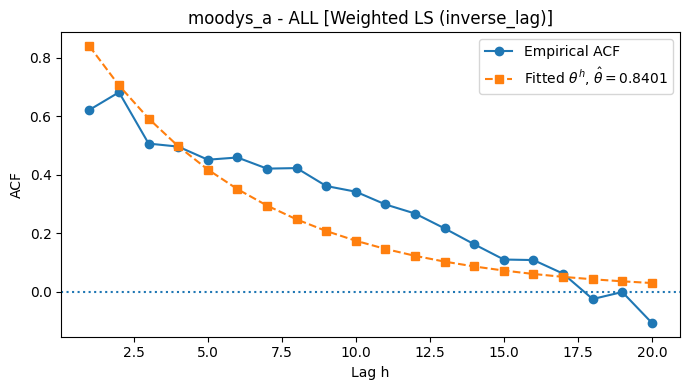

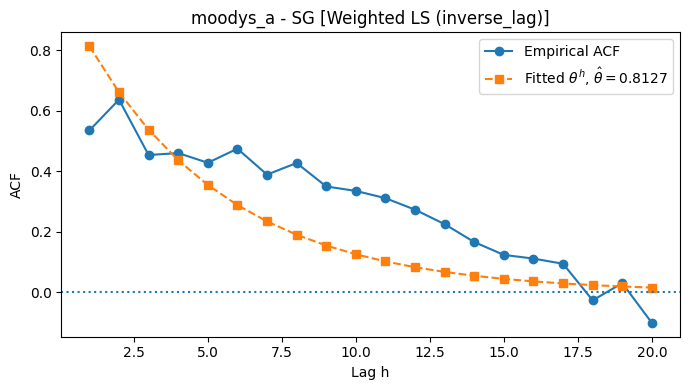

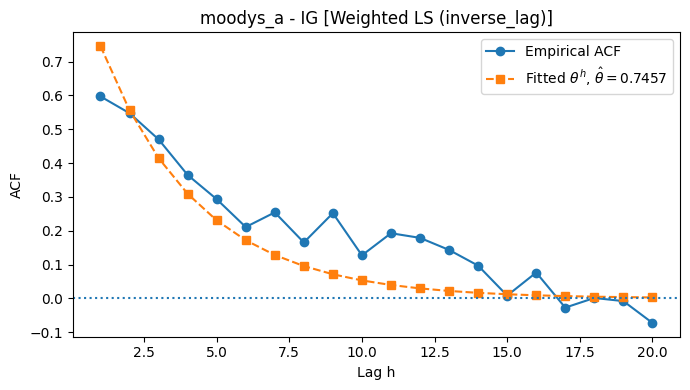

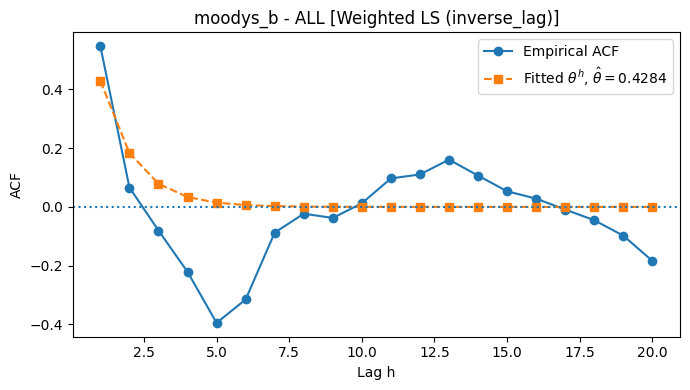

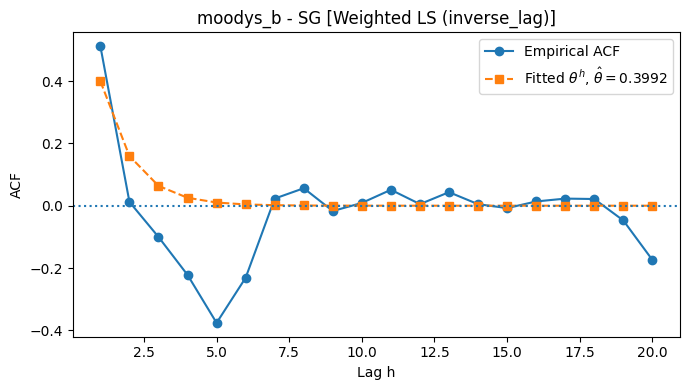

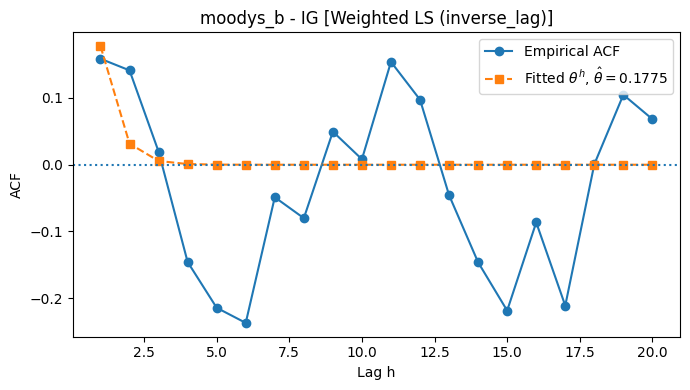

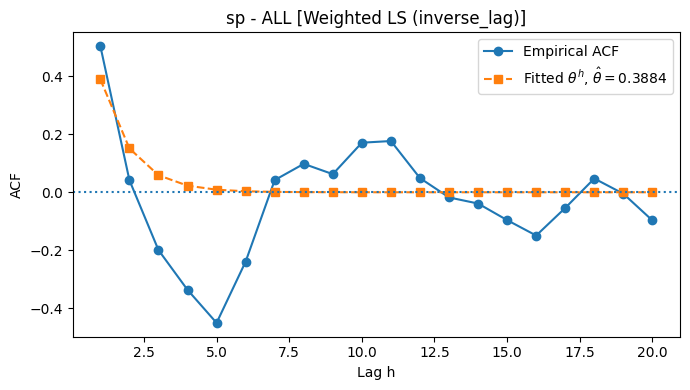

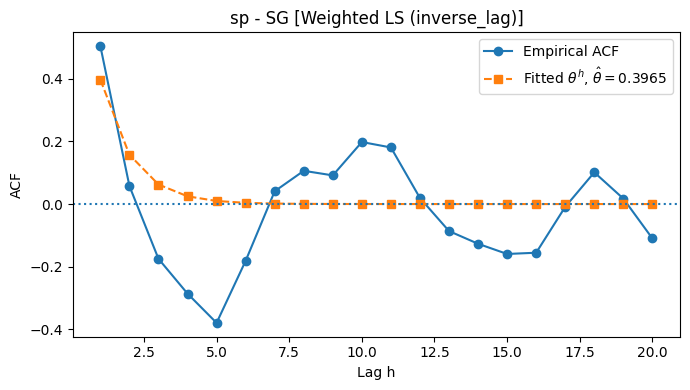

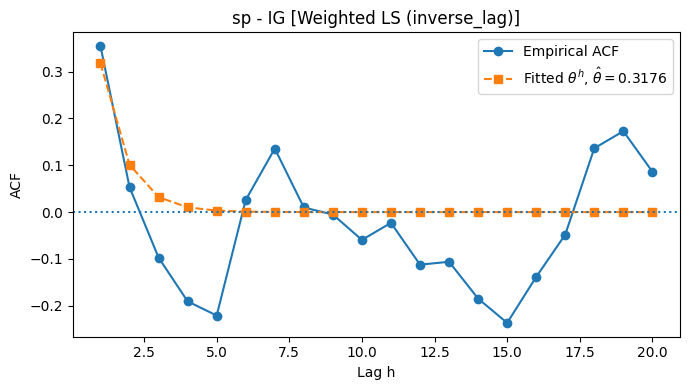

In [71]:
for data_name, df in data_dict.items():
    for col in col_list:
        result = fit_theta_by_acf(
            df[col], H=20, method="weighted", weight_type="inverse_lag"
        )
        plot_acf_fit(result, title=f"{data_name} - {col}")

### べき減衰
$$
d_h = \frac{1}{(1+h)^\gamma}, \qquad \gamma \ge 0
$$

### 推定量
$$
\hat{\gamma}
=
\operatorname*{argmin}_{\gamma \ge 0}
\sum_{h=1}^H
\frac{1}{h}
\left(
\hat{\rho}(h) - \frac{1}{(1+h)^\gamma}
\right)^2
$$

In [76]:
def fit_gamma_by_acf(
    y, H=20, method="weighted", fft=False, adjusted=False, weight_type="inverse_lag"
):
    """
    標本ACFに対して、べき減衰
        rho(h) = 1 / (1 + h)^gamma
    をフィットして gamma を推定する。
    """
    y = pd.Series(y).dropna().astype(float).values

    if len(y) <= H:
        raise ValueError(f"データ長 {len(y)} に対して H={H} は大きすぎます。")

    rho_hat = acf(y, nlags=H, fft=fft, adjusted=adjusted)
    lags = np.arange(1, H + 1)
    rho_target = rho_hat[1 : H + 1]

    if method == "ls":
        weights = np.ones(H)
    elif method == "weighted":
        if weight_type == "inverse_lag":
            weights = 1 / lags
        elif weight_type == "inverse_lag_sq":
            weights = 1 / (lags**2)
        else:
            raise ValueError(
                "weight_type は 'inverse_lag' または 'inverse_lag_sq' を指定してください。"
            )
    else:
        raise ValueError("method は 'ls' または 'weighted' を指定してください。")

    def objective(gamma):
        rho_model = 1 / ((1 + lags) ** gamma)
        return np.sum(weights * (rho_target - rho_model) ** 2)

    res = minimize_scalar(objective, bounds=(0.0, 5.0), method="bounded")

    gamma_hat = res.x
    rho_fitted = 1 / ((1 + lags) ** gamma_hat)

    return {
        "gamma_hat": gamma_hat,
        "objective": res.fun,
        "acf_empirical": rho_target,
        "acf_fitted": rho_fitted,
        "lags": lags,
        "weights": weights,
        "method": method,
        "weight_type": weight_type if method == "weighted" else None,
        "H": H,
        "success": res.success,
    }


def plot_acf_fit_power(result, title="ACF fit"):
    lags = result["lags"]
    rho_emp = result["acf_empirical"]
    rho_fit = result["acf_fitted"]
    gamma_hat = result["gamma_hat"]
    method = result["method"]

    if method == "ls":
        subtitle = "LS"
    else:
        subtitle = f"Weighted LS ({result['weight_type']})"

    plt.figure(figsize=(7, 4))
    plt.plot(lags, rho_emp, "o-", label="Empirical ACF")
    plt.plot(
        lags,
        rho_fit,
        "s--",
        label=rf"Fitted $(1+h)^{{-\gamma}}$, $\hat{{\gamma}}={gamma_hat:.4f}$",
    )
    plt.axhline(0, linestyle=":")
    plt.xlabel("Lag h")
    plt.ylabel("ACF")
    plt.title(f"{title} [{subtitle}]")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [77]:
def plot_acf_compare(
    y,
    H=20,
    method="weighted",
    fft=False,
    adjusted=False,
    weight_type="inverse_lag",
    title="ACF comparison",
):
    result_exp = fit_theta_by_acf(
        y, H=H, method=method, fft=fft, adjusted=adjusted, weight_type=weight_type
    )

    result_pow = fit_gamma_by_acf(
        y, H=H, method=method, fft=fft, adjusted=adjusted, weight_type=weight_type
    )

    lags = result_exp["lags"]
    rho_emp = result_exp["acf_empirical"]
    rho_exp = result_exp["acf_fitted"]
    rho_pow = result_pow["acf_fitted"]

    theta_hat = result_exp["theta_hat"]
    gamma_hat = result_pow["gamma_hat"]

    if method == "ls":
        subtitle = "LS"
    else:
        subtitle = f"Weighted LS ({weight_type})"

    plt.figure(figsize=(7, 4))
    plt.plot(lags, rho_emp, "o-", label="Empirical ACF")
    plt.plot(
        lags, rho_exp, "s--", label=rf"Exponential: $\hat{{\theta}}={theta_hat:.4f}$"
    )
    plt.plot(
        lags, rho_pow, "^-.", label=rf"Power-law: $\hat{{\gamma}}={gamma_hat:.4f}$"
    )
    plt.axhline(0, linestyle=":")
    plt.xlabel("Lag h")
    plt.ylabel("ACF")
    plt.title(f"{title} [{subtitle}]")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {"exp_result": result_exp, "power_result": result_pow}

In [78]:
data_dict = {
    "moodys_a": y_moodys_a,
    "moodys_b": y_moodys_b,
    "sp": df_sp,
}

col_list = ["ALL", "SG", "IG"]

results = []

for data_name, df in data_dict.items():
    for col in col_list:
        result = fit_gamma_by_acf(
            df[col], H=20, method="weighted", weight_type="inverse_lag"
        )

        results.append({
            "dataset": data_name,
            "group": col,
            "gamma_hat": result["gamma_hat"],
            "objective": result["objective"],
            "success": result["success"],
        })

gamma_table = pd.DataFrame(results)
gamma_table

,dataset,group,gamma_hat,objective,success
0,moodys_a,ALL,0.508958,0.033277,True
1,moodys_a,SG,0.566471,0.044378,True
2,moodys_a,IG,0.685032,0.015070,True
3,moodys_b,ALL,1.558320,0.158262,True
4,moodys_b,SG,1.653115,0.134932,True
5,moodys_b,IG,2.631087,0.043120,True
6,sp,ALL,1.715275,0.184668,True
7,sp,SG,1.661087,0.156151,True
8,sp,IG,1.936325,0.061878,True


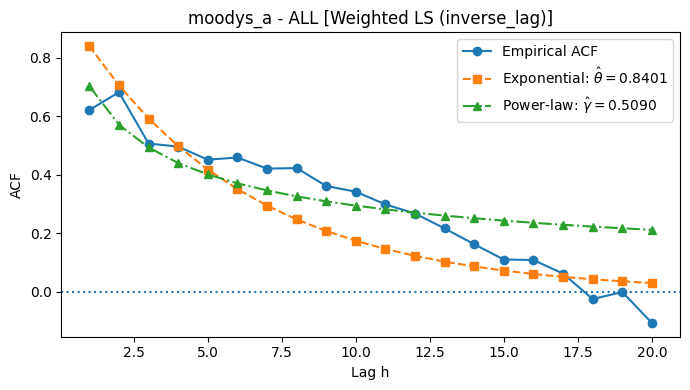

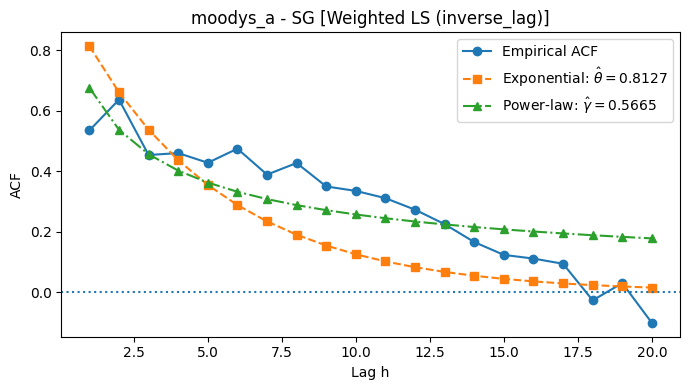

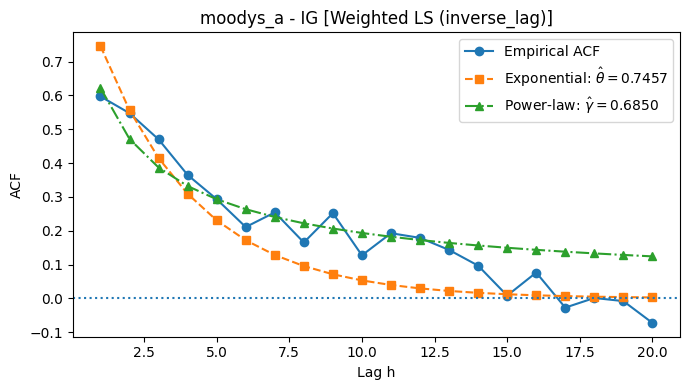

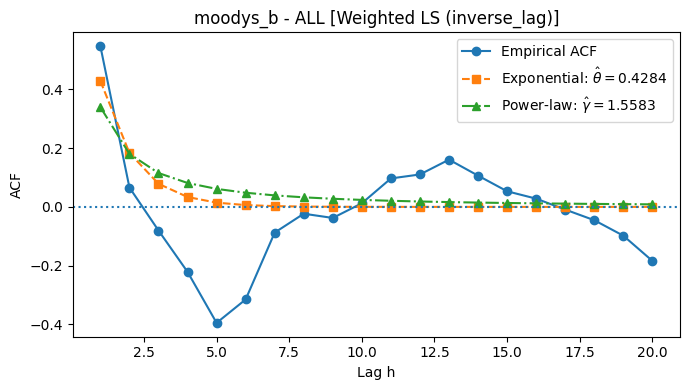

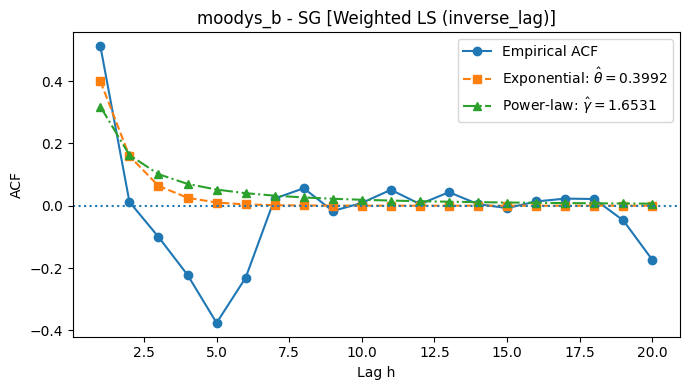

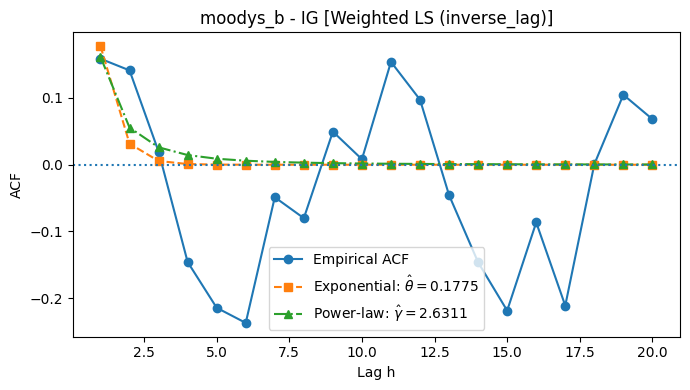

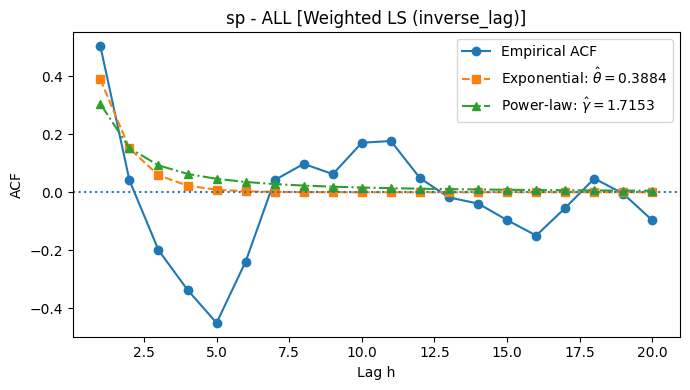

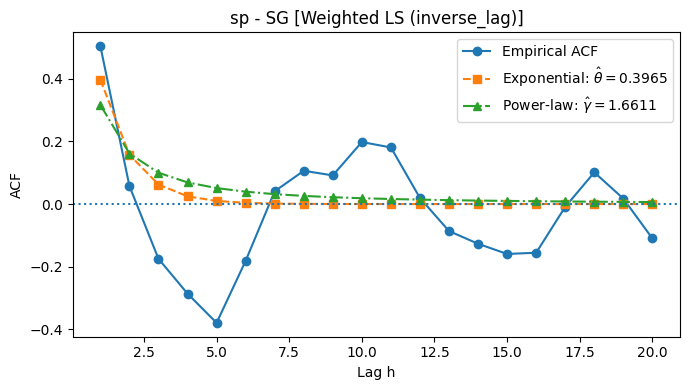

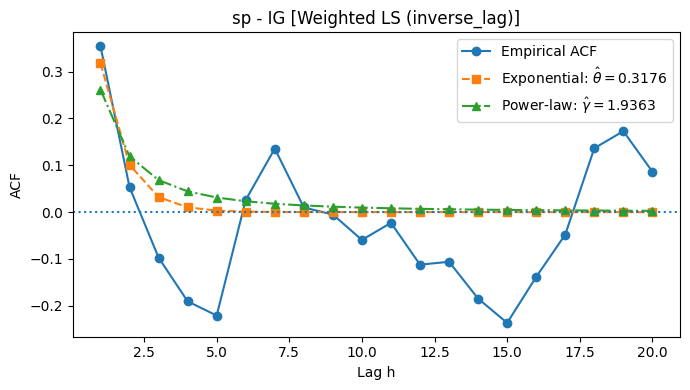

In [79]:
for data_name, df in data_dict.items():
    for col in col_list:
        plot_acf_compare(
            df[col],
            H=20,
            method="weighted",
            weight_type="inverse_lag",
            title=f"{data_name} - {col}",
        )

## 1920 - 2018のmoodysのみに絞る
データ数も多く、ある程度フィットもしている1920-2018のmoodysに絞る。

### 先行研究の結果

In [85]:
paper_moodys = paper_df[
    (paper_df["dataset"].str.contains("Moodys")) & (paper_df["period"] == "1920-2023")
].reset_index(drop=True)

paper_moodys

,dataset,period,lambda0_mle,alpha_mle,theta_acf,gamma_acf
0,Moodys ALL,1920-2023,18.1,1.4,0.89,0.64
1,Moodys SG,1920-2023,42.4,1.6,0.88,0.63
2,Moodys IG,1920-2023,0.6,2.5,0.84,0.74


### 最終的な初期値

In [86]:
results = []

col_list = ["ALL", "SG", "IG"]

for col in col_list:
    # --- lambda0, alpha0 の初期値 ---
    lambda0_init, alpha0_init = estimate_initial_lambda_alpha(df_moodys_a[col])

    # --- exponential ACF fit ---
    result_exp = fit_theta_by_acf(
        y_moodys_a[col], H=20, method="weighted", weight_type="inverse_lag"
    )

    # --- power-law ACF fit ---
    result_pow = fit_gamma_by_acf(
        y_moodys_a[col], H=20, method="weighted", weight_type="inverse_lag"
    )

    results.append({
        "group": col,
        # --- moment initial values ---
        "lambda0_init": lambda0_init,
        "alpha0_init": alpha0_init,
        # --- exponential ---
        "theta_hat": result_exp["theta_hat"],
        "theta_objective": result_exp["objective"],
        # --- power ---
        "gamma_hat": result_pow["gamma_hat"],
        "gamma_objective": result_pow["objective"],
        # --- optimization status ---
        "theta_success": result_exp["success"],
        "gamma_success": result_pow["success"],
    })

init_table_moodys_a = pd.DataFrame(results)
init_table_moodys_a[["group", "lambda0_init", "alpha0_init", "theta_hat", "gamma_hat"]]

,group,lambda0_init,alpha0_init,theta_hat,gamma_hat
0,ALL,22.745634,0.918828,0.840086,0.508958
1,SG,58.528809,0.855271,0.812694,0.566471
2,IG,2.090132,1.202780,0.745700,0.685032


In [ ]:
init_table_moodys_a[["group", "lambda0_init", "alpha0_init", "gamma_hat"]]

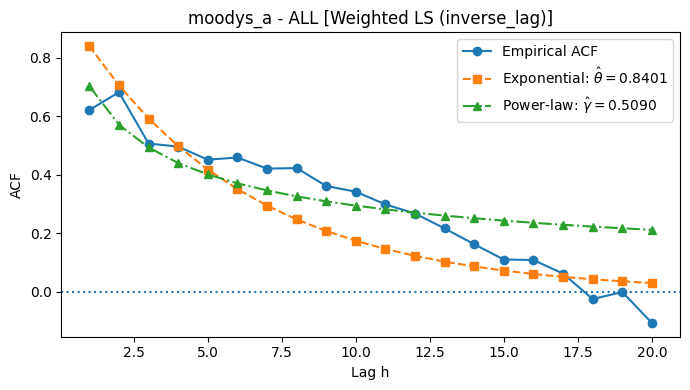

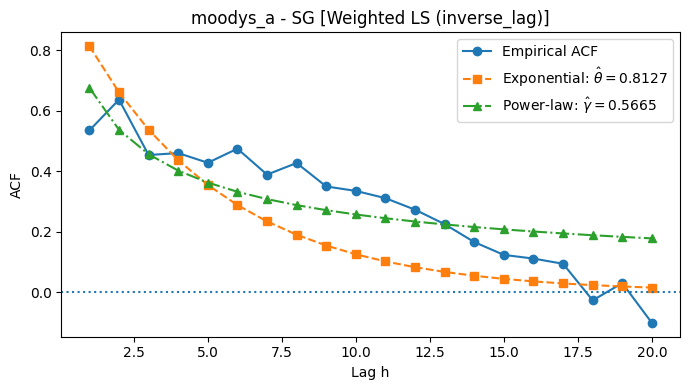

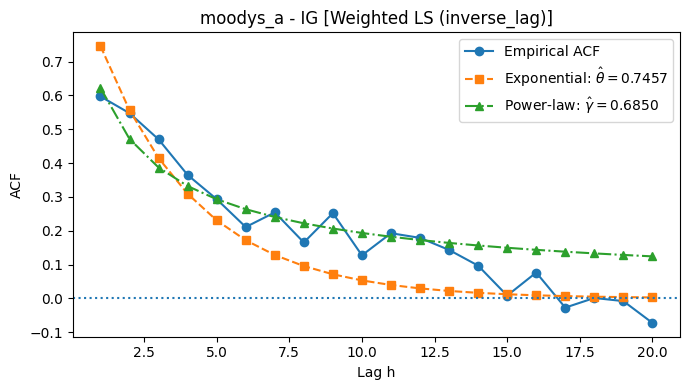

In [80]:
col_list = ["ALL", "SG", "IG"]

for col in col_list:
    plot_acf_compare(
        y_moodys_a[col],
        H=20,
        method="weighted",
        weight_type="inverse_lag",
        title=f"moodys_a - {col}",
    )

In [88]:
# 論文側
paper_moodys = paper_moodys.copy()
paper_moodys["group"] = ["ALL", "SG", "IG"]

paper_subset = paper_moodys[
    ["group", "lambda0_mle", "alpha_mle", "theta_acf", "gamma_acf"]
]

# 自分側
init_subset = init_table_moodys_a[
    ["group", "lambda0_init", "alpha0_init", "theta_hat", "gamma_hat"]
]

merged = pd.merge(init_subset, paper_subset, on="group", how="inner")

diff_init = merged.copy()

# --- 差分 ---
diff_init["lambda0_diff"] = diff_init["lambda0_init"] - diff_init["lambda0_mle"]
diff_init["alpha_diff"] = diff_init["alpha0_init"] - diff_init["alpha_mle"]
diff_init["theta_diff"] = diff_init["theta_hat"] - diff_init["theta_acf"]
diff_init["gamma_diff"] = diff_init["gamma_hat"] - diff_init["gamma_acf"]

# --- 列整理 ---
diff_init = diff_init[
    [
        "group",
        # 自分
        "lambda0_init",
        "alpha0_init",
        "theta_hat",
        "gamma_hat",
        # 論文
        "lambda0_mle",
        "alpha_mle",
        "theta_acf",
        "gamma_acf",
        # 差分
        "lambda0_diff",
        "alpha_diff",
        "theta_diff",
        "gamma_diff",
    ]
]

diff_init

,group,lambda0_init,alpha0_init,theta_hat,gamma_hat,lambda0_mle,alpha_mle,theta_acf,gamma_acf,lambda0_diff,alpha_diff,theta_diff,gamma_diff
0,ALL,22.745634,0.918828,0.840086,0.508958,18.1,1.4,0.89,0.64,4.645634,-0.481172,-0.049914,-0.131042
1,SG,58.528809,0.855271,0.812694,0.566471,42.4,1.6,0.88,0.63,16.128809,-0.744729,-0.067306,-0.063529
2,IG,2.090132,1.202780,0.745700,0.685032,0.6,2.5,0.84,0.74,1.490132,-1.297220,-0.094300,-0.054968


In [95]:
# import os

# os.makedirs("init_para", exist_ok=True)
# diff_init.to_csv((PROJECT_DATA_DIR / "pre/init_para/init.csv"), index=False)

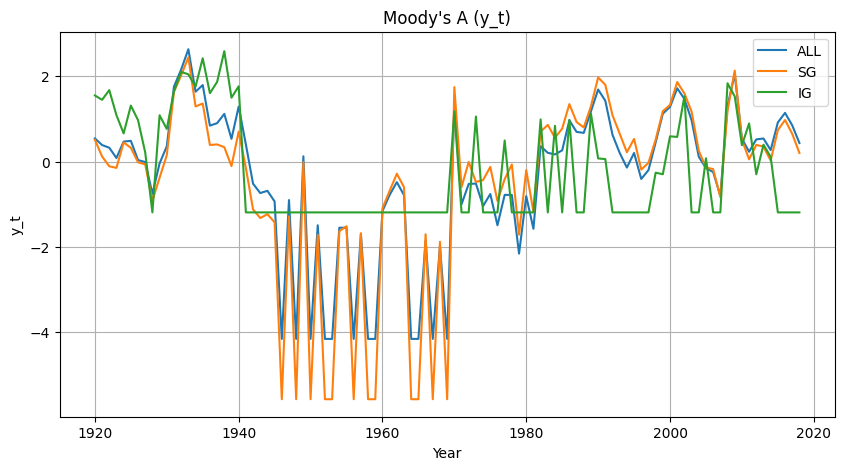

In [101]:
y_moodys_a = pd.DataFrame(index=df_moodys_a.index)

for col in ["ALL", "SG", "IG"]:
    lambda0_init, alpha0_init = estimate_initial_lambda_alpha(df_moodys_a[col])
    y_moodys_a[col] = restore_y(df_moodys_a[col], lambda0_init, alpha0_init)

plot_y(df_moodys_a, "Moody's A (y_t)")

In [98]:
y_moodys_a

,ALL,SG,IG
Year,,,
1920-01-01,0.544809,0.512842,1.552328
1921-01-01,0.389823,0.122405,1.450023
1922-01-01,0.326757,-0.107806,1.677164
1923-01-01,0.086248,-0.145897,1.089893
1924-01-01,0.470981,0.451065,0.662666
...,...,...,...
2014-01-01,0.272256,0.024898,0.111796
2015-01-01,0.919365,0.740582,-1.189223
2016-01-01,1.143809,0.976329,-1.189223


In [102]:
# os.makedirs("init_y", exist_ok=True)
# y_moodys_a.to_csv((PROJECT_DATA_DIR / "pre/init_y/y.csv"), index=True)